In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical

In [6]:
from google.colab import files
import zipfile
import os

if not os.path.exists("Datos lengua de seña.zip"):
  uploaded = files.upload()

with zipfile.ZipFile("Datos lengua de seña.zip", 'r') as zip_ref:
    zip_ref.extractall("letras")  # Creación de carpeta letras

Saving Datos lengua de seña.zip to Datos lengua de seña (1).zip


In [10]:
from PIL import Image
from sklearn.model_selection import train_test_split

base_path = "letras/Datos lengua de seña"

# Tamaño deseado de imagen
img_size = (28, 28)

X = []
y = []

# Obtener las clases (ordenadas alfabéticamente)
class_names = sorted(os.listdir(base_path))
label_map = {name: idx for idx, name in enumerate(class_names)}

# Cargar las imágenes
for label in class_names:
    folder = os.path.join(base_path, label)
    for file in os.listdir(folder):
        try:
            img_path = os.path.join(folder, file)
            img = Image.open(img_path).convert('L')  # Escala de grises
            img = img.resize(img_size)
            img_array = np.array(img)
            X.append(img_array)
            y.append(label_map[label])
        except:
            print(f"Error al leer: {img_path}")

# Convertir a arrays NumPy
X = np.array(X)
X = np.expand_dims(X, -1)  # (num_imágenes, 28, 28, 1)
y = np.array(y)

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# One-hot encoding
num_classes = len(class_names)
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)


In [11]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(num_classes, activation='softmax')  # ajuste al número real de clases
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train, batch_size=128, epochs=10, validation_split=0.1)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 16s 92ms/step - accuracy: 0.2116 - loss: 6.5222 - val_accuracy: 0.8789 - val_loss: 0.4453
Epoch 2/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 21s 95ms/step - accuracy: 0.8585 - loss: 0.4382 - val_accuracy: 0.9895 - val_loss: 0.0640
Epoch 3/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 20s 91ms/step - accuracy: 0.9617 - loss: 0.1247 - val_accuracy: 0.9950 - val_loss: 0.0185
Epoch 4/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 14s 91ms/step - accuracy: 0.9815 - loss: 0.0629 - val_accuracy: 0.9977 - val_loss: 0.0114
Epoch 5/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 20s 90ms/step - accuracy: 0.9865 - loss: 0.0456 - val_accuracy: 0.9991 - val_loss: 0.0072
Epoch 6/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 21s 96ms/step - accuracy: 0.9918 - loss: 0.0288 - val_accuracy: 0.9995 - val_loss: 0.0030
Epoch 7/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 19s 90ms/step - accuracy: 0.9946 - loss: 0.0196 - val_accuracy: 0.9995 - val_loss: 0.0045
Epoch 8/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 21s 92ms/step - accuracy: 0.9913 - loss: 0.0274 - 


Precisión en prueba: 1.0000


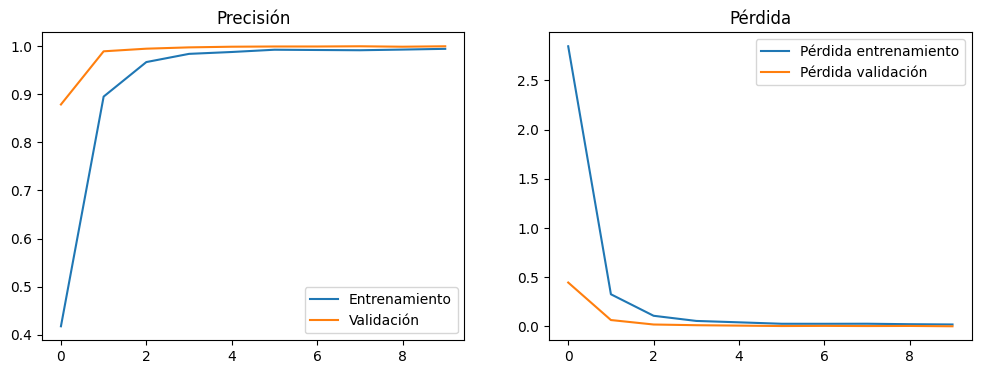

In [12]:
import matplotlib.pyplot as plt

# Evaluación del modelo
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nPrecisión en prueba: {test_acc:.4f}")

# Gráficas de entrenamiento
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Pérdida entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida validación')
plt.title('Pérdida')
plt.legend()
plt.show()
